In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [7]:
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/gev_fit_scores_kmeans_gev_k3.csv")

In [3]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/station_variable_statistics.csv")

In [8]:
import numpy as np
import pandas as pd

# --- Merge labels into stats ---
# Ensure station is comparable dtype
stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)

# Keep only station + cluster label from the GEV table
label_df = GEV_clusters[["station", "cluster"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on="station", how="inner")

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))


Stations for modeling: 279
cluster
1    136
0    122
2     21
Name: count, dtype: int64


In [10]:
model_df.columns

Index(['station', 'u10__mean', 'u10__std', 'u10__min', 'u10__max',
       'u10__median', 'u10__q05', 'u10__q95', 'u10__count',
       'u10__missing_frac',
       ...
       'residual_is_deviant__missing_frac', 'residual_is_deviant__annmax_mean',
       'residual_is_deviant__annmax_std', 'residual_is_deviant__annmax_min',
       'residual_is_deviant__annmax_max', 'residual_is_deviant__annmean_mean',
       'residual_is_deviant__annmean_std', 'residual_is_deviant__annmean_min',
       'residual_is_deviant__annmean_max', 'cluster'],
      dtype='object', length=257)

In [ ]:
# PCA: variance of the features

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


In [29]:
# Final columns to drop
# Explicit identifier columns
drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster']


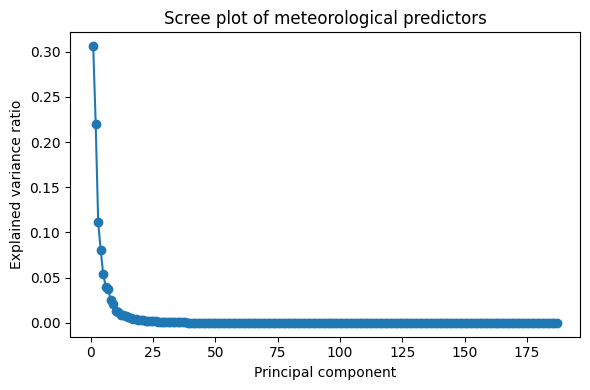

In [47]:
# PCA: variance of the features
# Standardise
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Scree plot of meteorological predictors")
plt.tight_layout()
plt.show()




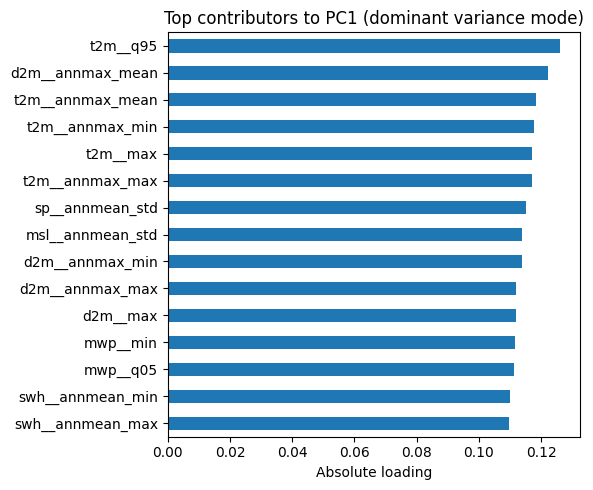

In [54]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
def top_loadings(loadings, pc, n=10):
    return loadings[pc].abs().sort_values(ascending=False).head(n)

pc = "PC1"
top_pc1 = loadings[pc].abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(6, 5))
top_pc1.sort_values().plot(kind="barh")
plt.xlabel("Absolute loading")
plt.title("Top contributors to PC1 (dominant variance mode)")
plt.tight_layout()
plt.show()


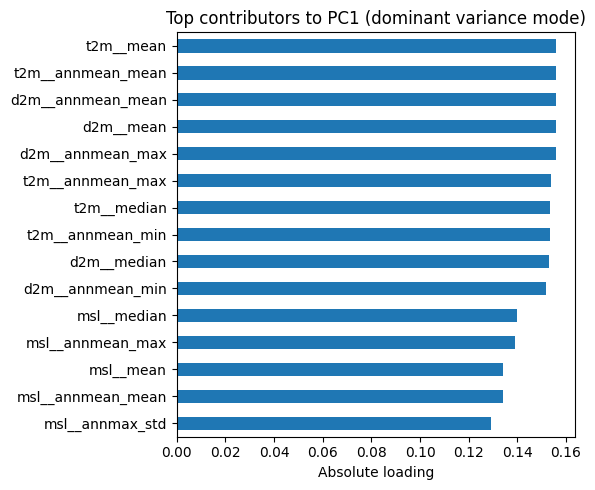

In [55]:
pc = "PC2"
top_pc1 = loadings[pc].abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(6, 5))
top_pc1.sort_values().plot(kind="barh")
plt.xlabel("Absolute loading")
plt.title("Top contributors to PC1 (dominant variance mode)")
plt.tight_layout()
plt.show()


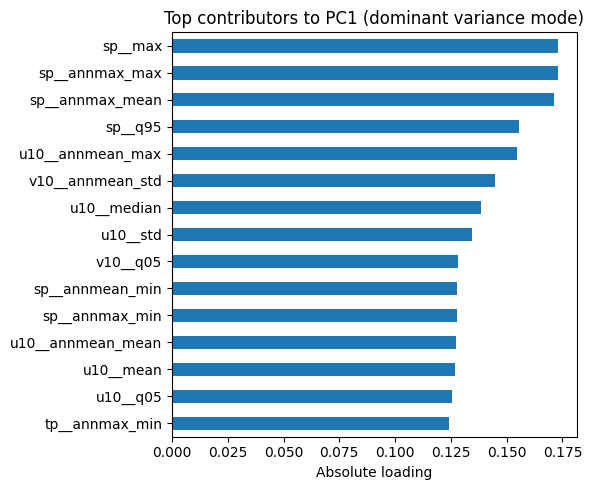

In [56]:
pc = "PC3"
top_pc1 = loadings[pc].abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(6, 5))
top_pc1.sort_values().plot(kind="barh")
plt.xlabel("Absolute loading")
plt.title("Top contributors to PC1 (dominant variance mode)")
plt.tight_layout()
plt.show()


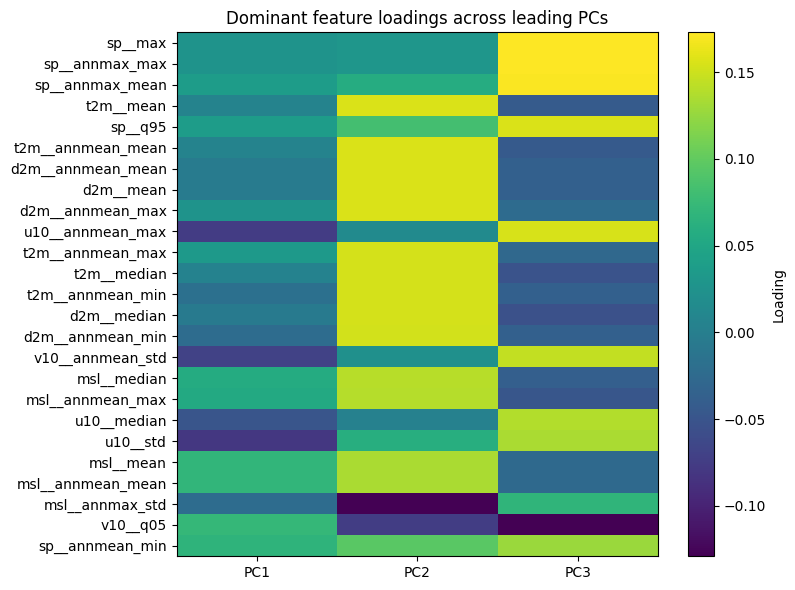

In [57]:
pcs = ["PC1", "PC2", "PC3"]
top_features = (
    loadings[pcs]
    .abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .head(25)
    .index
)

plt.figure(figsize=(8, 6))
plt.imshow(loadings.loc[top_features, pcs], aspect="auto")
plt.colorbar(label="Loading")
plt.yticks(range(len(top_features)), top_features)
plt.xticks(range(len(pcs)), pcs)
plt.title("Dominant feature loadings across leading PCs")
plt.tight_layout()
plt.show()


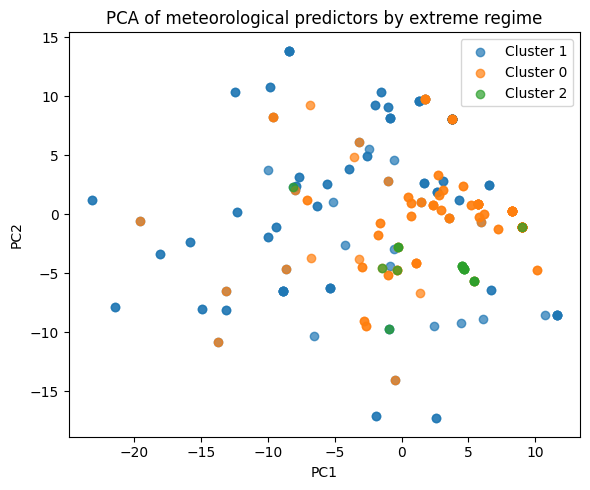

The largest sources of variance in meteorological statistics are not the same as the features that define extreme sea-level regimes.


In [59]:
pc_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"],
    index=model_df.index
)
pc_df["cluster"] = model_df["cluster"]

plt.figure(figsize=(6, 5))
for c in pc_df["cluster"].unique():
    subset = pc_df[pc_df["cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of meteorological predictors by extreme regime")
plt.tight_layout()
plt.show()

print("The largest sources of variance in meteorological statistics are not the same as the features that define extreme sea-level regimes.")


In [30]:
X.columns

Index(['u10__mean', 'u10__std', 'u10__min', 'u10__max', 'u10__median',
       'u10__q05', 'u10__q95', 'u10__count', 'u10__missing_frac',
       'u10__annmax_mean',
       ...
       'swh__count', 'swh__missing_frac', 'swh__annmax_mean',
       'swh__annmax_std', 'swh__annmax_min', 'swh__annmax_max',
       'swh__annmean_mean', 'swh__annmean_std', 'swh__annmean_min',
       'swh__annmean_max'],
      dtype='object', length=187)

In [31]:
X = X.fillna(X.median())
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=500,
        penalty="l2"
    ))
])

pipe.fit(X, y)


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(max_iter=500, multi_class='multinomial'))])

In [32]:
coef = pipe.named_steps["clf"].coef_
classes = pipe.named_steps["clf"].classes_

coef_df = pd.DataFrame(
    coef,
    index=classes,
    columns=X.columns
)


In [33]:
coef_df

,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__count,u10__missing_frac,u10__annmax_mean,...,swh__count,swh__missing_frac,swh__annmax_mean,swh__annmax_std,swh__annmax_min,swh__annmax_max,swh__annmean_mean,swh__annmean_std,swh__annmean_min,swh__annmean_max
0,0.256523,-0.080451,0.154852,-0.523612,0.080062,-0.053517,-0.068746,0.0,0.0,0.20776,...,0.127818,-0.127818,0.025779,-0.139649,0.254989,0.128667,0.109431,-0.459846,0.109435,-0.026521
1,-0.330538,-0.060988,-0.161604,0.541503,-0.089285,0.168853,-0.094722,0.0,0.0,-0.39999,...,-0.007109,0.007109,-0.030941,0.046909,-0.235676,-0.163581,-0.025980,0.438784,-0.028334,0.081446
2,0.074015,0.141439,0.006751,-0.017891,0.009223,-0.115336,0.163469,0.0,0.0,0.19223,...,-0.120710,0.120710,0.005163,0.092740,-0.019313,0.034914,-0.083451,0.021063,-0.081101,-0.054925


In [34]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
scores.mean(), scores.std()


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-pa

(0.6949350649350649, 0.09753272692652315)

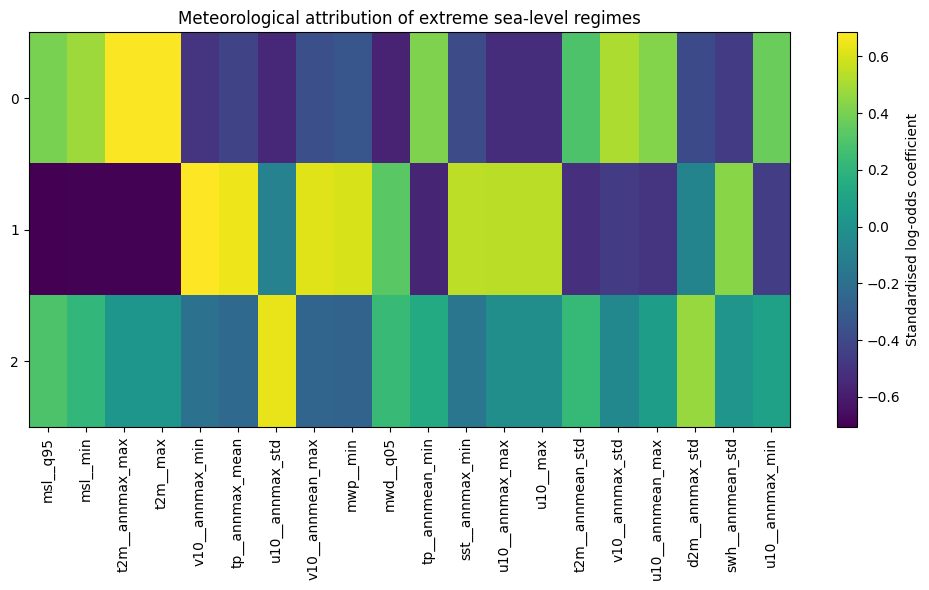

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Select most influential predictors across clusters
abs_mean = coef_df.abs().mean(axis=0)
top_features = abs_mean.sort_values(ascending=False).head(20).index

coef_top = coef_df[top_features]

plt.figure(figsize=(10, 6))
im = plt.imshow(coef_top, aspect="auto")
plt.colorbar(im, label="Standardised log-odds coefficient")

plt.yticks(range(len(coef_top.index)), coef_top.index)
plt.xticks(range(len(top_features)), top_features, rotation=90)

plt.title("Meteorological attribution of extreme sea-level regimes")
plt.tight_layout()
plt.show()


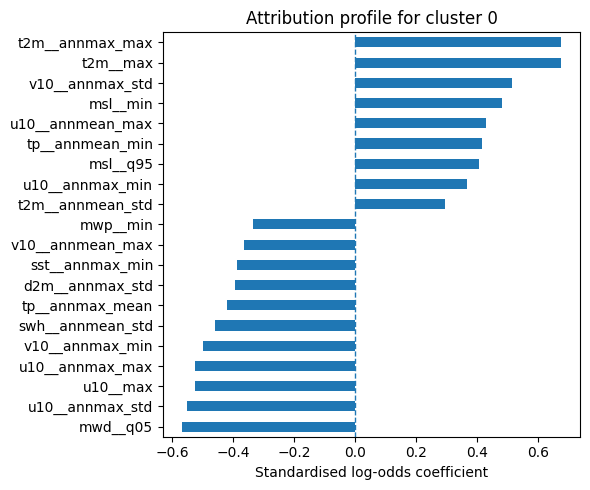

In [36]:
cluster_id = coef_df.index[0]  # choose cluster of interest

coef_cluster = coef_df.loc[cluster_id, top_features].sort_values()

plt.figure(figsize=(6, 5))
coef_cluster.plot(kind="barh")
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Standardised log-odds coefficient")
plt.title(f"Attribution profile for cluster {cluster_id}")
plt.tight_layout()
plt.show()


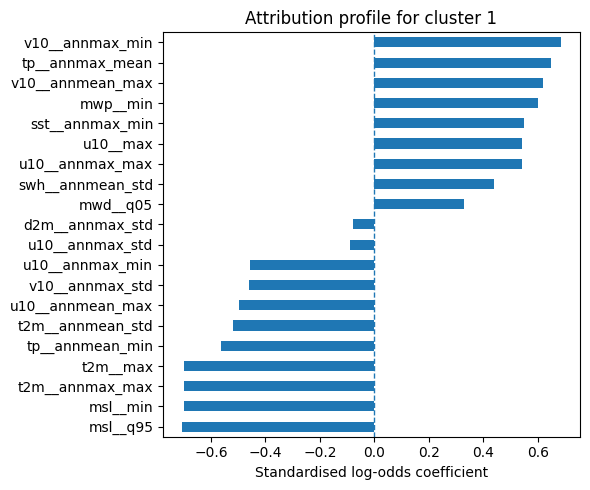

In [37]:
cluster_id = coef_df.index[1]  # choose cluster of interest

coef_cluster = coef_df.loc[cluster_id, top_features].sort_values()

plt.figure(figsize=(6, 5))
coef_cluster.plot(kind="barh")
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Standardised log-odds coefficient")
plt.title(f"Attribution profile for cluster {cluster_id}")
plt.tight_layout()
plt.show()


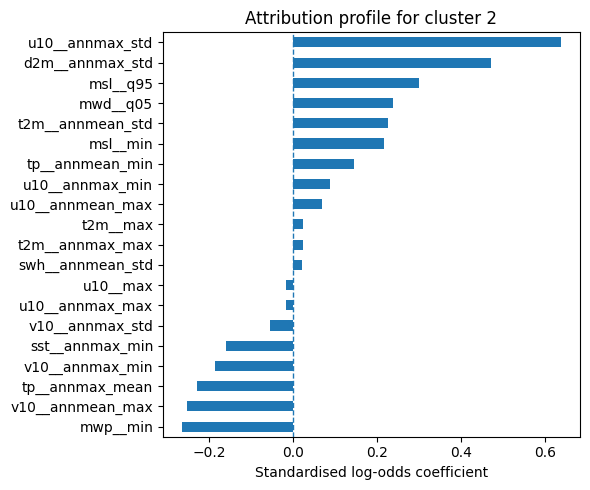

In [38]:
cluster_id = coef_df.index[2]  # choose cluster of interest

coef_cluster = coef_df.loc[cluster_id, top_features].sort_values()

plt.figure(figsize=(6, 5))
coef_cluster.plot(kind="barh")
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Standardised log-odds coefficient")
plt.title(f"Attribution profile for cluster {cluster_id}")
plt.tight_layout()
plt.show()


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-pa

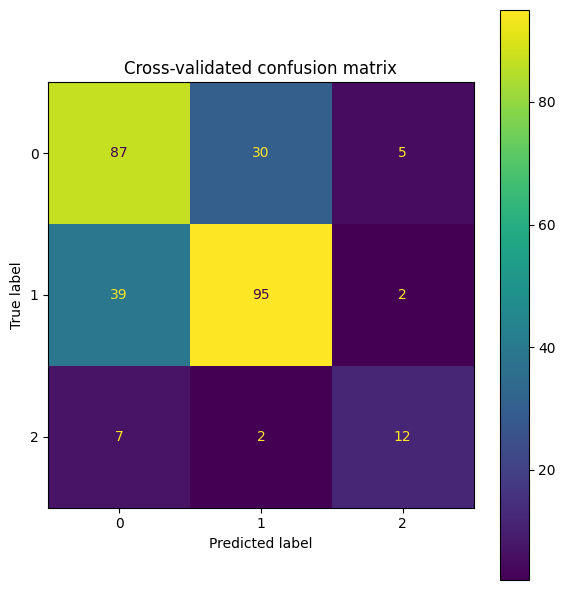

In [39]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = cross_val_predict(pipe, X, y, cv=5)

cm = confusion_matrix(y, y_pred, labels=pipe.named_steps["clf"].classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipe.named_steps["clf"].classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
ax.set_title("Cross-validated confusion matrix")
plt.tight_layout()
plt.show()


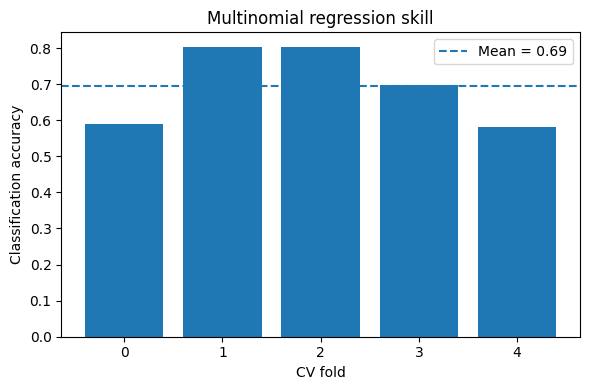

In [40]:
plt.figure(figsize=(6, 4))
plt.bar(range(len(scores)), scores)
plt.axhline(scores.mean(), linestyle="--", label=f"Mean = {scores.mean():.2f}")

plt.xlabel("CV fold")
plt.ylabel("Classification accuracy")
plt.title("Multinomial regression skill")
plt.legend()
plt.tight_layout()
plt.show()


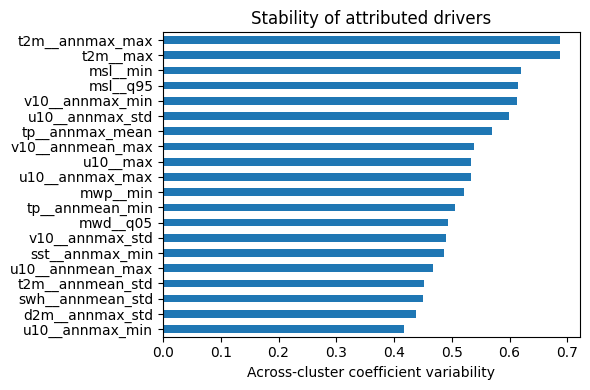

In [41]:
coef_std = coef_df[top_features].std(axis=0)

plt.figure(figsize=(6, 4))
coef_std.sort_values().plot(kind="barh")
plt.xlabel("Across-cluster coefficient variability")
plt.title("Stability of attributed drivers")
plt.tight_layout()
plt.show()


In [25]:
# Final columns to drop
# Explicit identifier columns
drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", )

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])


In [26]:
X.head()

,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__count,u10__missing_frac,u10__annmax_mean,...,residual_is_deviant__count,residual_is_deviant__missing_frac,residual_is_deviant__annmax_mean,residual_is_deviant__annmax_std,residual_is_deviant__annmax_min,residual_is_deviant__annmax_max,residual_is_deviant__annmean_mean,residual_is_deviant__annmean_std,residual_is_deviant__annmean_min,residual_is_deviant__annmean_max
0,1.435309,5.204763,-16.211533,26.093597,1.500458,-6.847014,10.088026,750192,0.0,18.495850,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
1,1.033226,4.597254,-15.020645,23.730011,0.919975,-6.038169,8.888404,750192,0.0,17.695318,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
2,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,10.497694,750192,0.0,18.720236,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
3,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,10.497694,750192,0.0,18.720236,...,750192,0.0,0.127907,0.333986,0,1,0.008964,0.039935,0.0,0.241667
4,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,10.497694,750192,0.0,18.720236,...,750192,0.0,0.069767,0.254755,0,1,0.002223,0.014116,0.0,0.104736


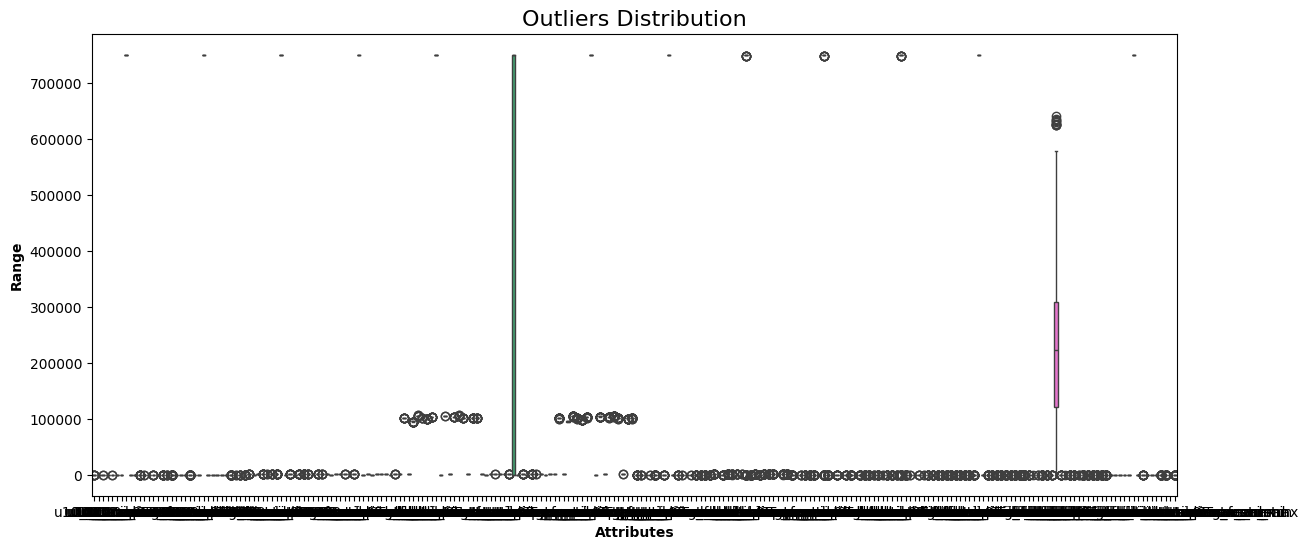

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
def show_boxplot(df):
    plt.rcParams['figure.figsize'] = [14,6]
    sns.boxplot(data = df, orient="v")
    plt.title("Outliers Distribution", fontsize = 16)
    plt.ylabel("Range", fontweight = 'bold')
    plt.xlabel("Attributes", fontweight = 'bold')
   
show_boxplot(X)

In [ ]:
def remove_outliers(data):
    df = data.copy()
    for col in list(df.columns):

      Q1 = df[str(col)].quantile(0.05)
      Q3 = df[str(col)].quantile(0.95)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5*IQR
      upper_bound = Q3 + 1.5*IQR
 
      df = df[(df[str(col)] >= lower_bound) & 

        (df[str(col)] <= upper_bound)]
   
    return df

without_outliers = remove_outliers(X)


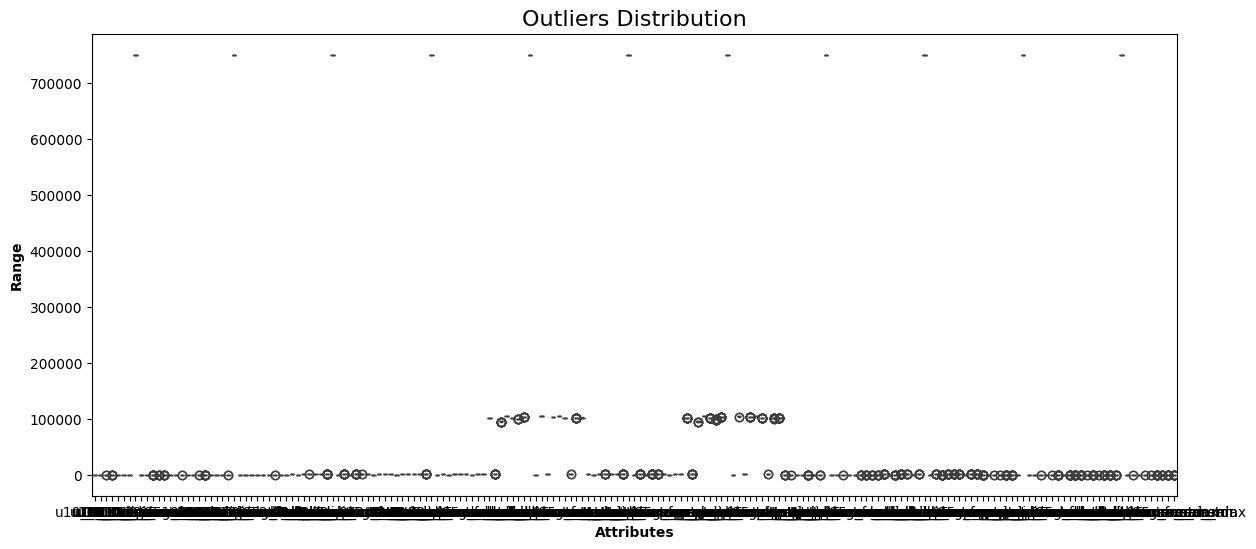

In [28]:
show_boxplot(without_outliers)

In [29]:
without_outliers.shape

(148, 187)

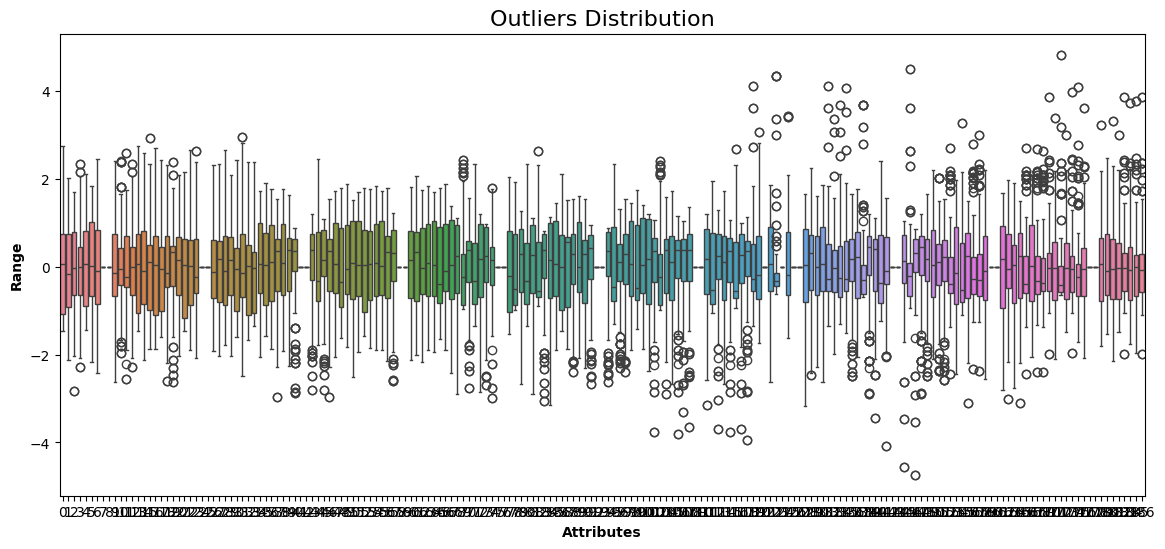

In [30]:
from sklearn.preprocessing import StandardScaler

data_scaler = StandardScaler()

scaled_data = data_scaler.fit_transform(without_outliers)
scaled_data.shape
show_boxplot(scaled_data)

In [31]:
from scipy.cluster.hierarchy import linkage, dendrogram

complete_clustering = linkage(scaled_data, method="complete", metric="euclidean")
average_clustering = linkage(scaled_data, method="average", metric="euclidean")
single_clustering = linkage(scaled_data, method="single", metric="euclidean")

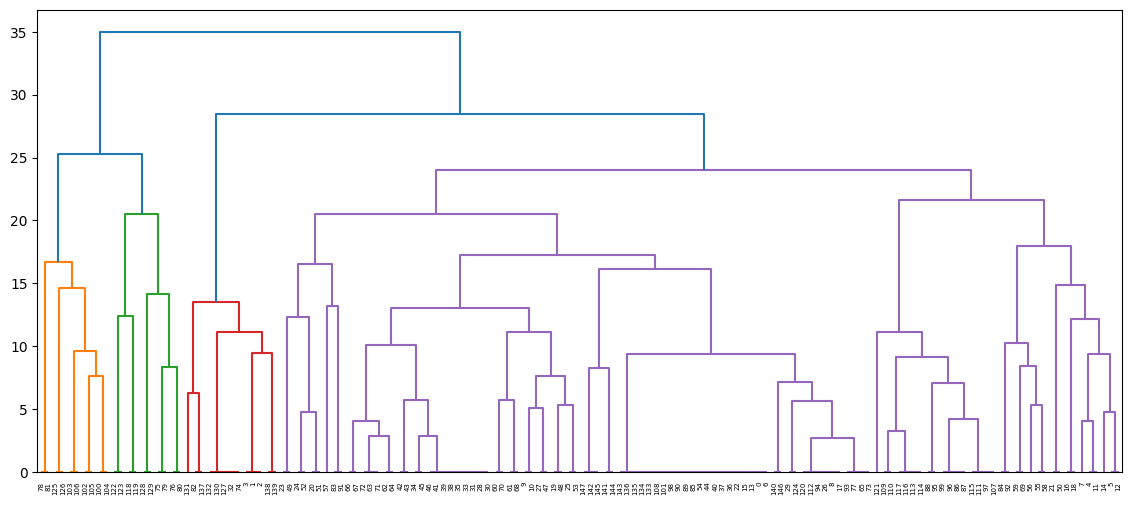

In [32]:
dendrogram(complete_clustering)
plt.show()

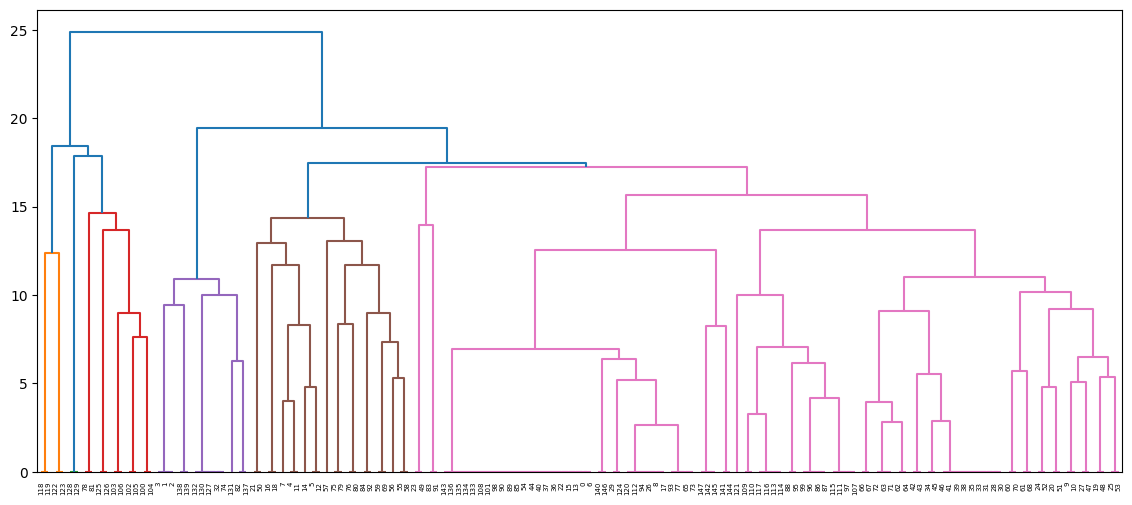

In [33]:
dendrogram(average_clustering)
plt.show()

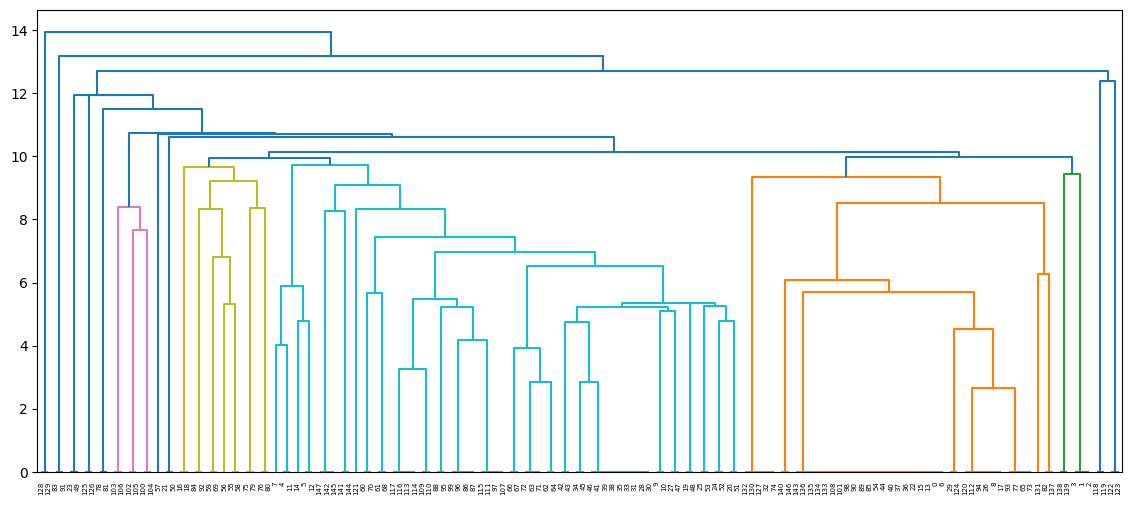

In [34]:
dendrogram(single_clustering)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier


# --- Separate X, y ---
y = model_df["cluster"].astype(int)

# Explicit identifier columns
drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ("residual", "sea_level", "tide")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}

# Final columns to drop
cols_to_drop = drop_cols | forbidden_cols

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

# Keep numeric only and clean
X = (
    X.select_dtypes(include=[np.number])
     .replace([np.inf, -np.inf], np.nan)
)


# Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

# Model pipeline: impute -> tree classifier
clf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(random_state=0))
])

clf.fit(X_train, y_train)

print("Test accuracy:", clf.score(X_test, y_test))
print("\nClassification report:\n", classification_report(y_test, clf.predict(X_test)))
print("Confusion matrix:\n", confusion_matrix(y_test, clf.predict(X_test)))


Test accuracy: 0.7142857142857143

Classification report:
               precision    recall  f1-score   support

           0       0.65      0.77      0.71        31
           1       0.80      0.71      0.75        34
           2       0.67      0.40      0.50         5

    accuracy                           0.71        70
   macro avg       0.71      0.63      0.65        70
weighted avg       0.72      0.71      0.71        70

Confusion matrix:
 [[24  6  1]
 [10 24  0]
 [ 3  0  2]]


In [9]:
import shap

# Get fitted components
imputer = clf.named_steps["imputer"]
tree_model = clf.named_steps["model"]

# Transform data for SHAP (imputed numeric matrix)
X_train_imp = imputer.transform(X_train)
X_test_imp  = imputer.transform(X_test)

feature_names = X.columns.tolist()

# SHAP explainer
explainer = shap.TreeExplainer(tree_model)

# Multiclass: shap_values is typically (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_test_imp)

# Create a SHAP-friendly DataFrame for plots
X_test_imp_df = pd.DataFrame(X_test_imp, columns=feature_names)


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


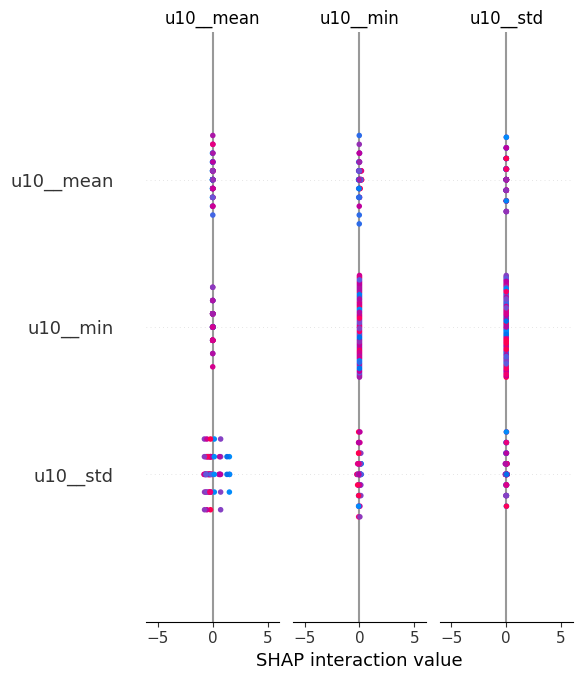

In [10]:
shap.summary_plot(shap_values, X_test_imp_df)   # in notebooks / interactive


SHAP summary for class/cluster 0


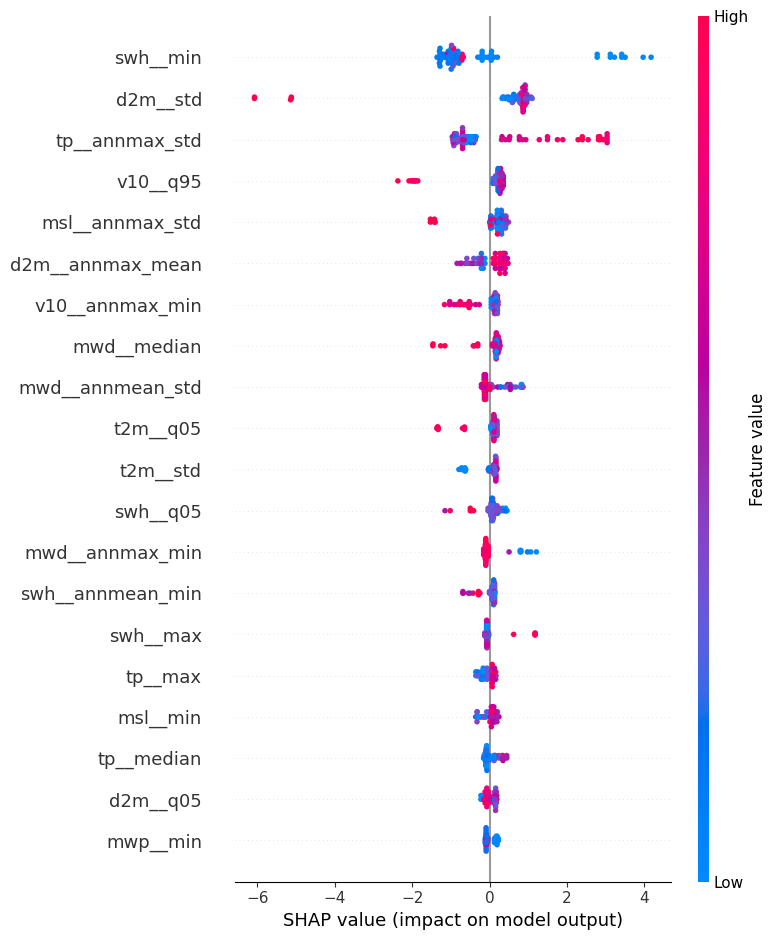

SHAP summary for class/cluster 1


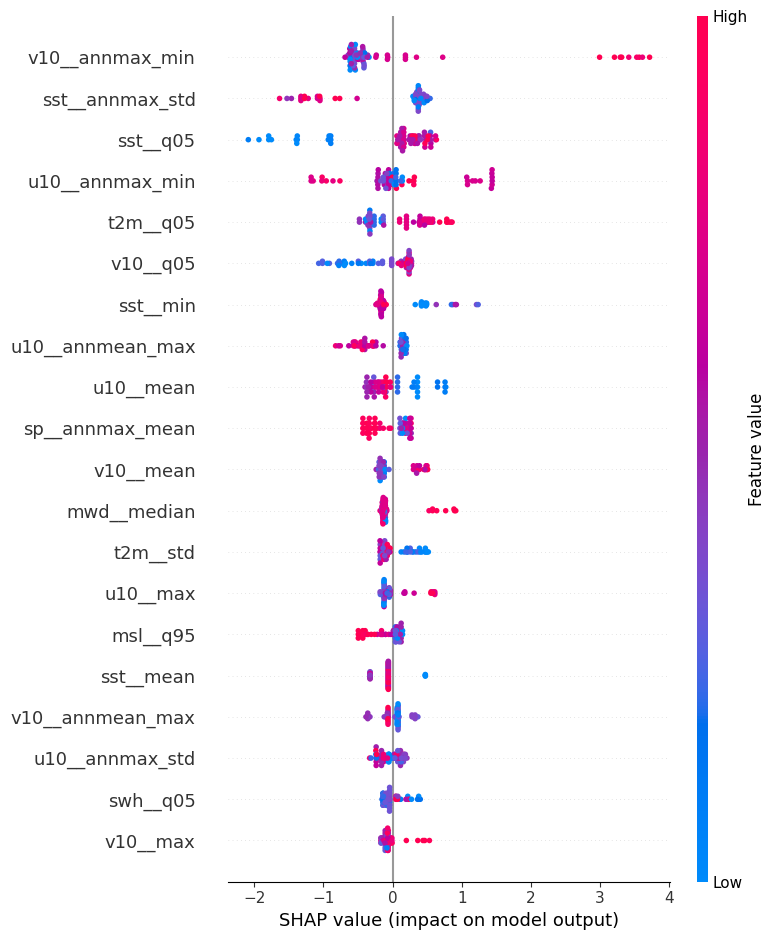

SHAP summary for class/cluster 2


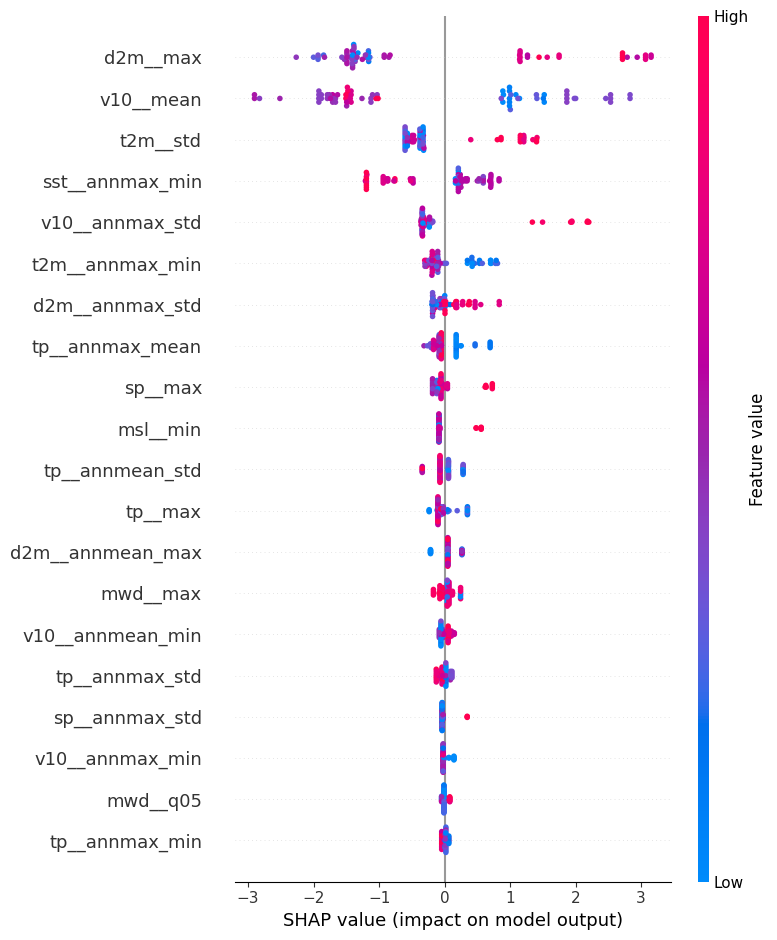

In [11]:
k = len(np.unique(y))
for c in range(k):
    print(f"SHAP summary for class/cluster {c}")
    shap.summary_plot(shap_values[:, :, c], X_test_imp_df, show=True)


This produces a able of the top 15 drivers per cluster by mean absolute SHAP among stations that truly belong to that cluster (in the test set).

In [25]:
# Indices for each true cluster in test set
topn = 15
drivers = {}

for c in sorted(np.unique(y_test)):
    idx = np.where(y_test.values == c)[0]
    mean_abs = np.abs(shap_values[idx, :, c]).mean(axis=0)
    s = pd.Series(mean_abs, index=feature_names).sort_values(ascending=False).head(topn)
    drivers[c] = s

drivers_df = pd.DataFrame(drivers)
drivers_df.columns = [f"cluster_{c}" for c in drivers_df.columns]
print(drivers_df)


                  cluster_0  cluster_1  cluster_2
d2m__annmax_mean   0.306008        NaN        NaN
d2m__annmax_std         NaN        NaN   0.415558
d2m__annmean_max        NaN        NaN   0.092122
d2m__max                NaN        NaN   2.771861
d2m__q05           0.146196        NaN        NaN
d2m__std           0.838355        NaN        NaN
msl__annmax_std    0.317906        NaN        NaN
msl__min                NaN        NaN   0.270557
msl__q95                NaN   0.169382        NaN
mwd__annmean_std   0.138963        NaN        NaN
mwd__max                NaN        NaN   0.204149
mwd__median        0.280957   0.225307        NaN
sp__annmax_mean         NaN   0.211275        NaN
sp__annmax_std          NaN        NaN   0.156433
sp__max                 NaN        NaN   0.356223
sst__annmax_min         NaN        NaN   0.664560
sst__annmax_std         NaN   0.440975        NaN
sst__min                NaN   0.292659        NaN
sst__q05                NaN   0.404094        NaN


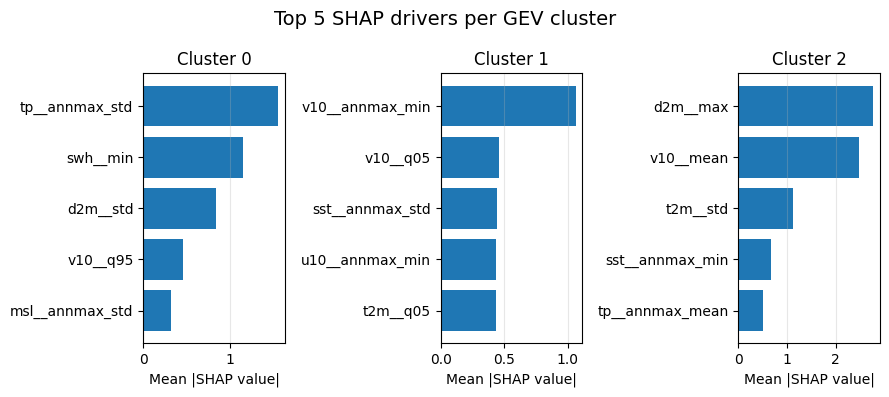

In [33]:
import matplotlib.pyplot as plt
import numpy as np

topn = 5
clusters = sorted(np.unique(y_test))

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(clusters),
    figsize=(3 * len(clusters), 4),
    sharey=False
)

if len(clusters) == 1:
    axes = [axes]

for ax, c in zip(axes, clusters):
    idx = np.where(y_test.values == c)[0]

    mean_abs = np.abs(shap_values[idx, :, c]).mean(axis=0)
    s = (
        pd.Series(mean_abs, index=feature_names)
        .sort_values(ascending=False)
        .head(topn)
        .sort_values()  # for horizontal bar ordering
    )

    ax.barh(s.index, s.values)
    ax.set_title(f"Cluster {c}")
    ax.set_xlabel("Mean |SHAP value|")
    ax.grid(axis="x", alpha=0.3)

fig.suptitle("Top 5 SHAP drivers per GEV cluster", fontsize=14)
plt.tight_layout()
plt.show()


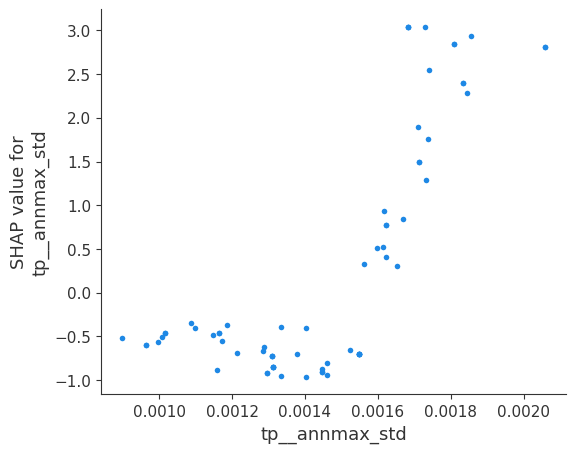

In [26]:
c = 0
top_feature = drivers[c].index[0]
fi = feature_names.index(top_feature)

shap.dependence_plot(
    fi,
    shap_values[:, :, c],
    X_test_imp_df,
    interaction_index=None
)


In [27]:
import pandas as pd
import shap

imputer = clf.named_steps["imputer"]
model = clf.named_steps["model"]

X_test_imp = imputer.transform(X_test)
X_test_imp_df = pd.DataFrame(X_test_imp, columns=X_test.columns)

explainer = shap.TreeExplainer(model)

# shap_values: (n_samples, n_features, n_classes) for most multiclass tree models
shap_values = explainer.shap_values(X_test_imp)

# Expected values per class
base_values = explainer.expected_value


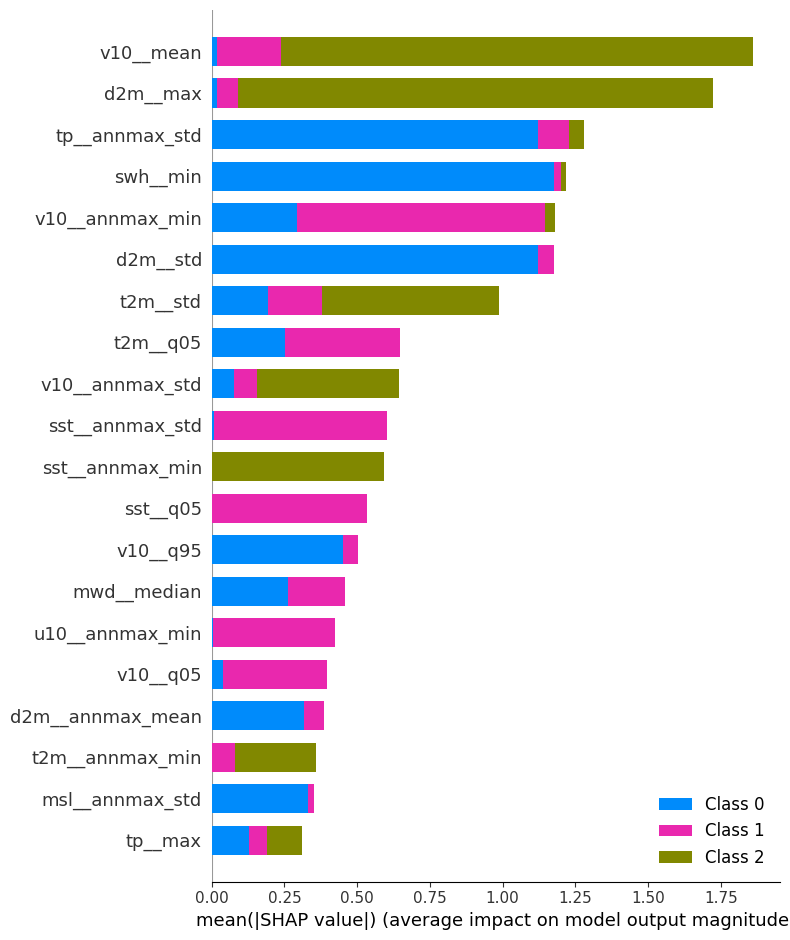

In [28]:
shap.summary_plot(shap_values, X_test_imp_df, plot_type="bar")


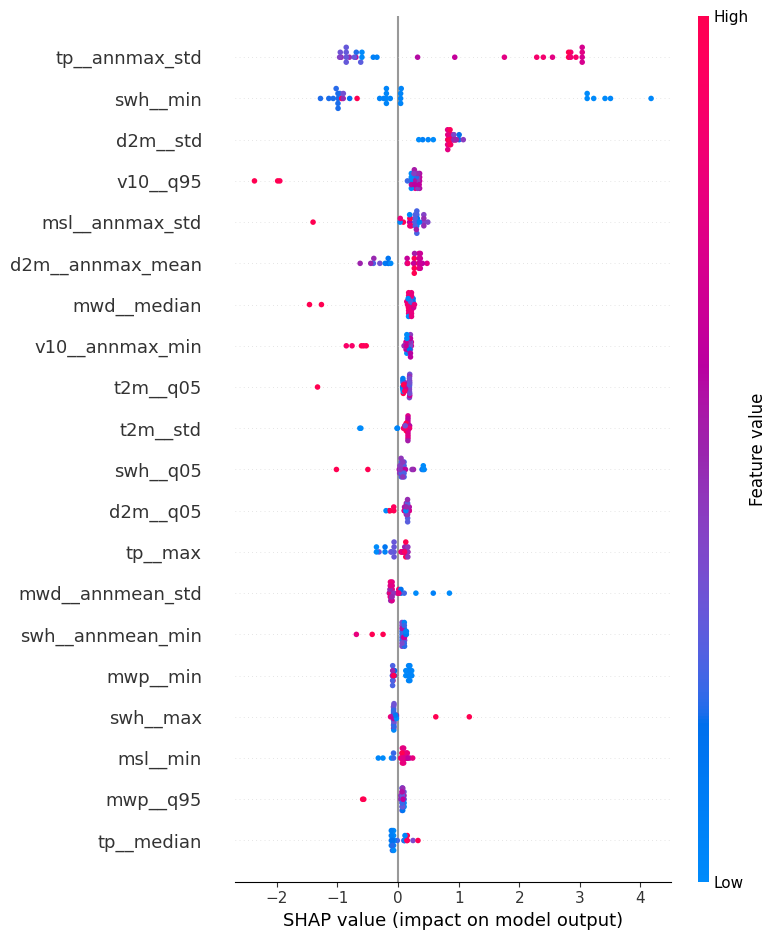

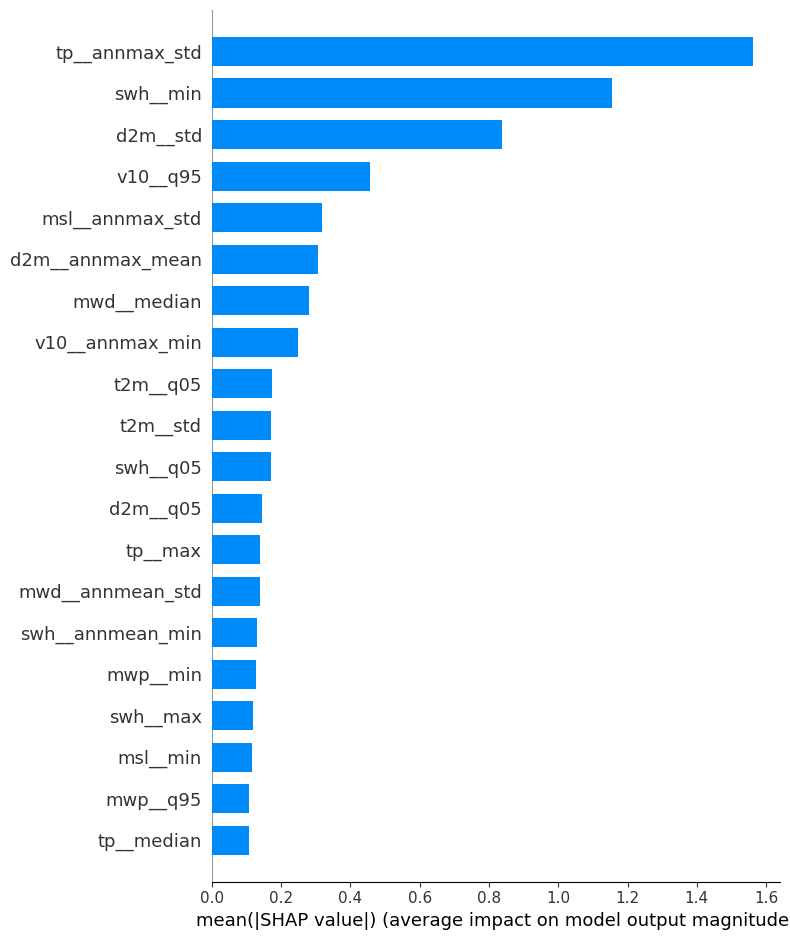

In [16]:
import numpy as np

c = 0
idx = np.where(y_test.values == c)[0]

shap.summary_plot(shap_values[idx, :, c], X_test_imp_df.iloc[idx, :], show=True)
shap.summary_plot(shap_values[idx, :, c], X_test_imp_df.iloc[idx, :], plot_type="bar", show=True)



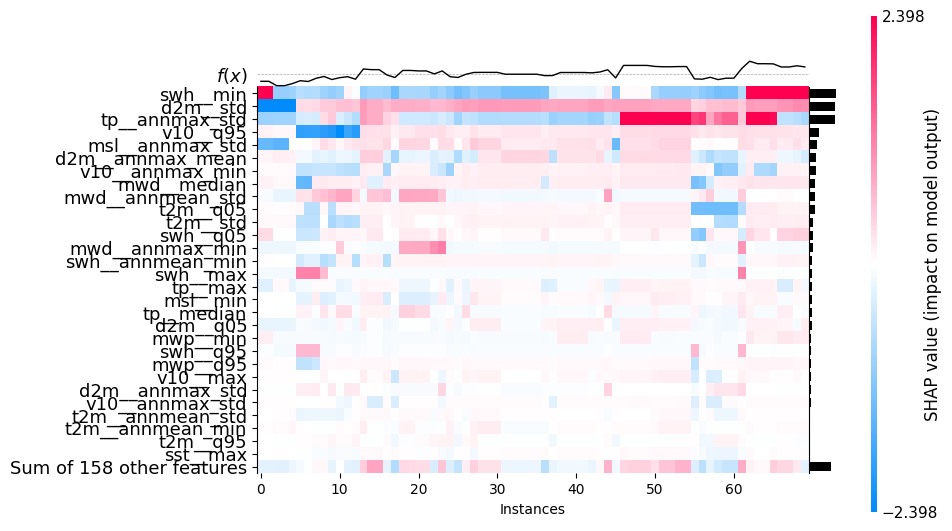

<Axes: xlabel='Instances'>

In [17]:
c = 0
exp_mat = shap.Explanation(
    values=shap_values[:, :, c],
    base_values=(base_values[c] if isinstance(base_values, (list, np.ndarray)) else base_values),
    data=X_test_imp_df.values,
    feature_names=X_test.columns
)
shap.plots.heatmap(exp_mat, max_display=30)


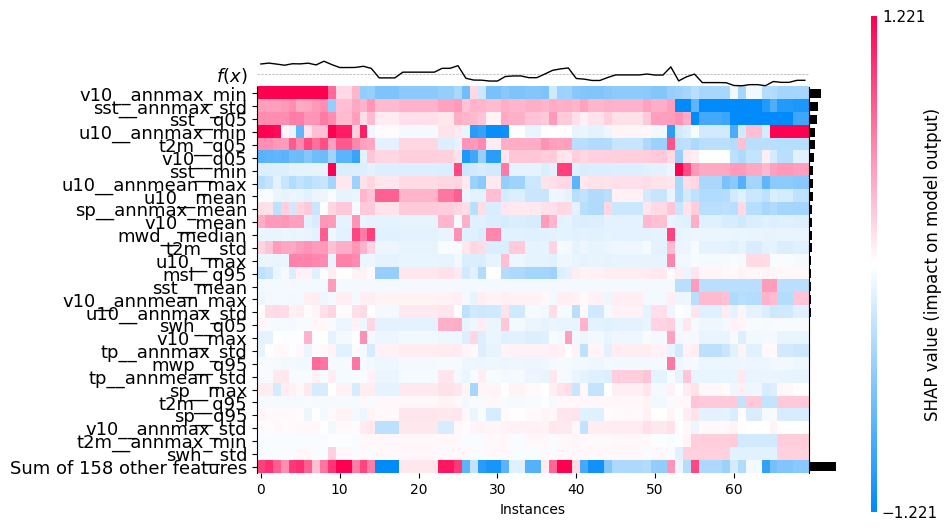

<Axes: xlabel='Instances'>

In [18]:
c = 1
exp_mat = shap.Explanation(
    values=shap_values[:, :, c],
    base_values=(base_values[c] if isinstance(base_values, (list, np.ndarray)) else base_values),
    data=X_test_imp_df.values,
    feature_names=X_test.columns
)
shap.plots.heatmap(exp_mat, max_display=30)


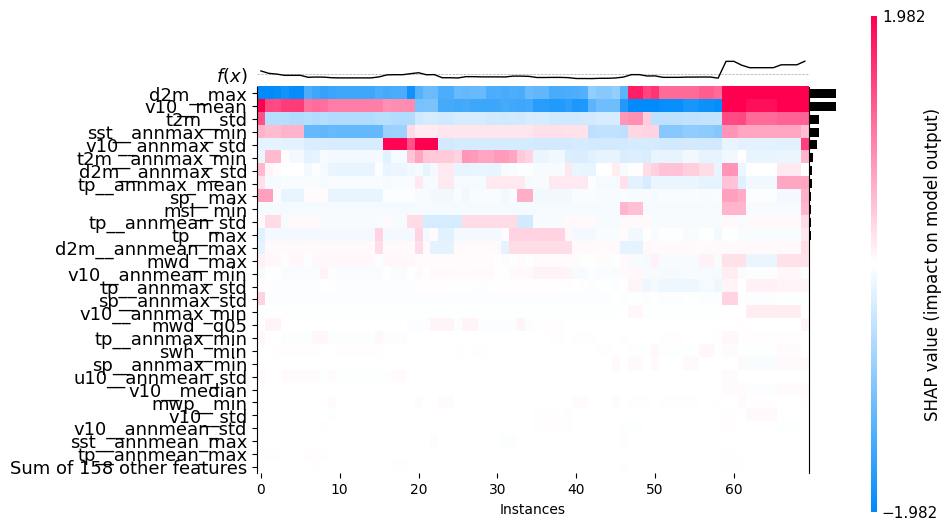

<Axes: xlabel='Instances'>

In [19]:
c = 2
exp_mat = shap.Explanation(
    values=shap_values[:, :, c],
    base_values=(base_values[c] if isinstance(base_values, (list, np.ndarray)) else base_values),
    data=X_test_imp_df.values,
    feature_names=X_test.columns
)
shap.plots.heatmap(exp_mat, max_display=30)


In [20]:
stats_df.to_csv("station_variable_statistics.csv", index=False)


In [21]:
# Variable group definitions
WEATHER_VARS = ["u10", "v10", "d2m", "t2m", "sst", "tp"]
WAVE_VARS    = ["msl", "mwd", "mwp", "swh"]

In [22]:
def select_group_columns(stats_df, var_list):
    cols = []
    for v in var_list:
        cols.extend([c for c in stats_df.columns if c.startswith(f"{v}__")])
    return cols


In [23]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

def cluster_group(stats_df, group_cols, k_range=range(2, 9), random_state=0):
    # 1) Select columns and coerce to numeric
    Xdf = stats_df.loc[:, group_cols].apply(pd.to_numeric, errors="coerce")

    # 2) Drop columns that are entirely NaN (common for annual stats if short records)
    Xdf = Xdf.dropna(axis=1, how="all")
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric columns found for this group after coercion.")

    # 3) Force a real float array (prevents object dtype causing isfinite failure)
    X = Xdf.to_numpy(dtype=float)

    # 4) Keep only rows that are fully finite
    mask = np.isfinite(X).all(axis=1)
    Xc = X[mask]
    if Xc.shape[0] < 3:
        raise ValueError("Not enough valid stations (rows) after dropping NaNs/infs.")

    # 5) Standardize
    scaler = StandardScaler()
    Xs = scaler.fit_transform(Xc)

    # 6) Silhouette scan
    sil_scores = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = km.fit_predict(Xs)
        sil_scores[k] = silhouette_score(Xs, labels)

    best_k = max(sil_scores, key=sil_scores.get)

    # 7) Final fit with best k
    km = KMeans(n_clusters=best_k, random_state=random_state, n_init="auto")
    labels_final = km.fit_predict(Xs)

    # 8) Map labels back to original df length
    out = np.full(len(stats_df), np.nan)
    out[mask] = labels_final

    return out, best_k, sil_scores, Xdf.columns.tolist()


In [24]:
weather_cols = select_group_columns(stats_df, WEATHER_VARS)
stats_df["cluster_weather"], k_weather, sil_weather, used_weather_cols = cluster_group(stats_df, weather_cols)

wave_cols = select_group_columns(stats_df, WAVE_VARS)
stats_df["cluster_waves"], k_waves, sil_waves, used_wave_cols = cluster_group(stats_df, wave_cols)

tide_cols = select_group_columns(stats_df, TIDE_VARS)
stats_df["cluster_tide"], k_tide, sil_tide, used_tide_cols = cluster_group(stats_df, tide_cols)

NameError: name 'TIDE_VARS' is not defined

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.lines import Line2D

def plot_cluster_map(
    df,
    cluster_col,
    title,
    projection=ccrs.PlateCarree(),
):
    # Drop stations without coords or cluster
    dfp = df.dropna(subset=["latitude", "lon", cluster_col]).copy()
    dfp[cluster_col] = dfp[cluster_col].astype(int)

    clusters = np.sort(dfp[cluster_col].unique())
    n_clusters = len(clusters)

    cmap = plt.get_cmap("tab10", n_clusters)

    fig = plt.figure(figsize=(9, 6))
    ax = plt.axes(projection=projection)

    # Background
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)

    # Map extent with padding
    pad = 2.0
    ax.set_extent(
        [
            dfp["lon"].min() - pad,
            dfp["lon"].max() + pad,
            dfp["lat"].min() - pad,
            dfp["lat"].max() + pad,
        ],
        crs=ccrs.PlateCarree(),
    )

    # Plot each cluster separately for legend control
    handles = []
    for i, cl in enumerate(clusters):
        dfi = dfp[dfp[cluster_col] == cl]
        sc = ax.scatter(
            dfi["lon"],
            dfi["lat"],
            s=70,
            color=cmap(i),
            edgecolor="k",
            transform=ccrs.PlateCarree(),
            label=f"Cluster {cl}",
            zorder=3,
        )

        handles.append(
            Line2D(
                [0], [0],
                marker="o",
                color="w",
                label=f"Cluster {cl}",
                markerfacecolor=cmap(i),
                markeredgecolor="k",
                markersize=9,
            )
        )

    ax.set_title(title)
    ax.legend(handles=handles, loc="lower left", frameon=True)

    plt.tight_layout()
    plt.show()


In [ ]:
# Extract station coordinates from ds
station_coords = (
    ds[["station_latitude", "station_longitude"]]
    .to_dataframe()
    .reset_index()
    .rename(columns={
        "station_latitude": "lat",
        "station_longitude": "lon",
    })
)

# Merge into stats_df
stats_df = stats_df.merge(
    station_coords[["station", "lat", "lon"]],
    on="station",
    how="left",
)


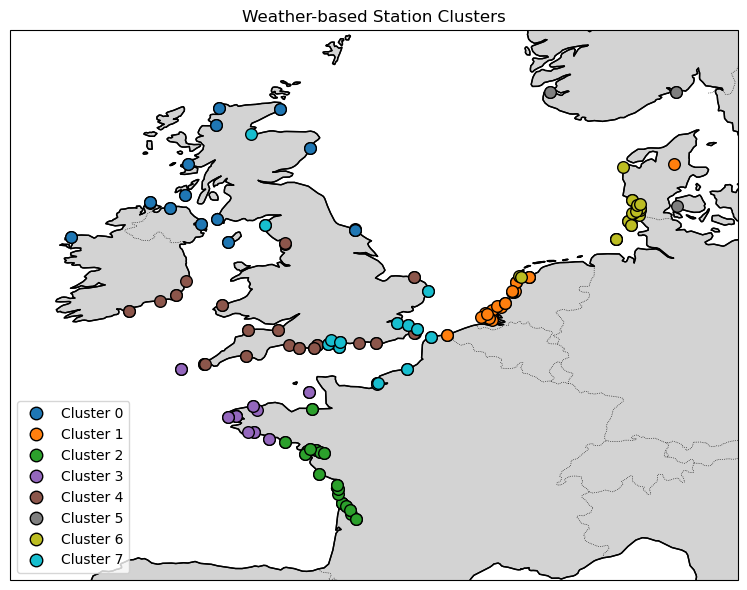

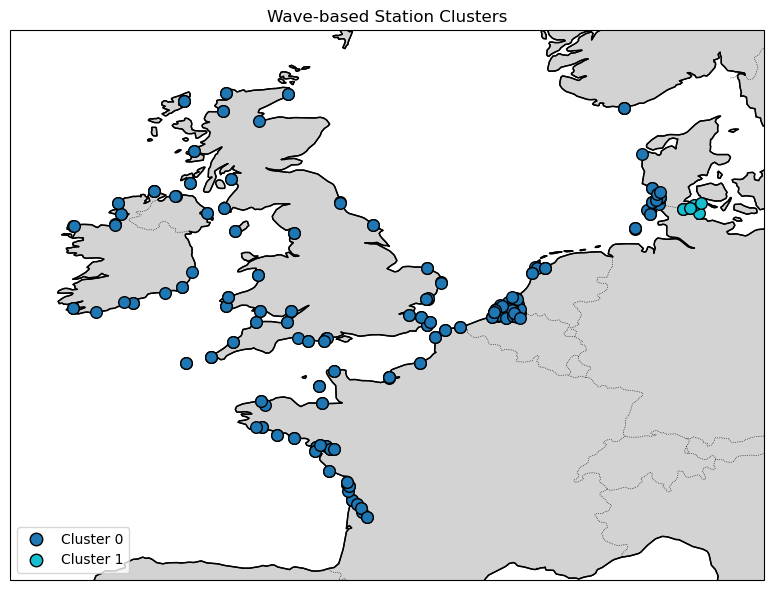

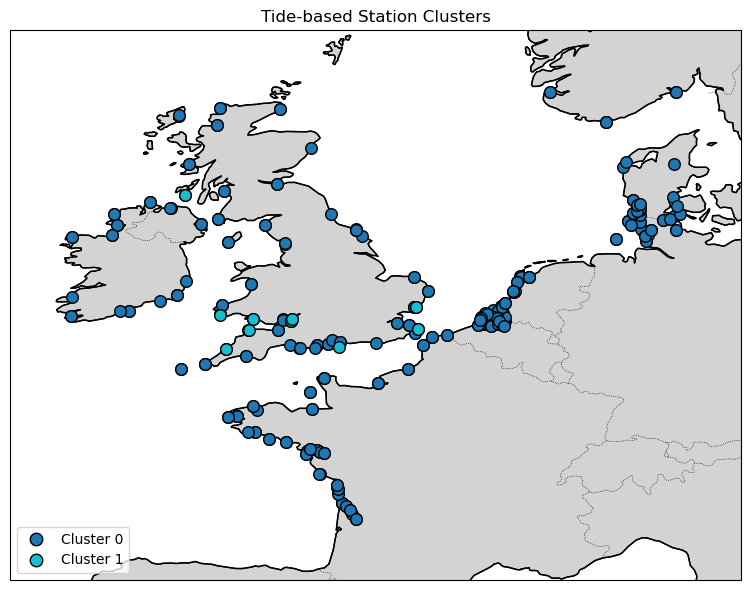

In [ ]:
plot_cluster_map(
    stats_df,
    cluster_col="cluster_weather",
    title="Weather-based Station Clusters",
)

plot_cluster_map(
    stats_df,
    cluster_col="cluster_waves",
    title="Wave-based Station Clusters",
)

plot_cluster_map(
    stats_df,
    cluster_col="cluster_tide",
    title="Tide-based Station Clusters",
)


In [ ]:
print("Weather clusters:")
print(stats_df["cluster_weather"].value_counts(dropna=False))

print("\nWave clusters:")
print(stats_df["cluster_waves"].value_counts(dropna=False))

print("\nTide clusters:")
print(stats_df["cluster_tide"].value_counts(dropna=False))

print(f"Weather: best k = {k_weather}")
print(f"Waves:   best k = {k_waves}")
print(f"Tide:    best k = {k_tide}")



Weather clusters:
cluster_weather
NaN    103
2.0     33
4.0     33
0.0     29
1.0     28
7.0     26
6.0     20
3.0     18
5.0      5
Name: count, dtype: int64

Wave clusters:
cluster_waves
0.0    226
NaN     62
1.0      7
Name: count, dtype: int64

Tide clusters:
cluster_tide
0.0    269
NaN     16
1.0     10
Name: count, dtype: int64
Weather: best k = 8
Waves:   best k = 2
Tide:    best k = 2
